In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook

In [4]:
df = pd.read_csv('techstore_chile_2024.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mes              300 non-null    int64  
 1   categoria        300 non-null    str    
 2   unidades         300 non-null    int64  
 3   precio_unitario  300 non-null    float64
 4   ingresos         300 non-null    float64
 5   nps              300 non-null    int64  
 6   devueltos        300 non-null    int64  
dtypes: float64(2), int64(4), str(1)
memory usage: 16.5 KB


In [9]:
df.isnull().sum()

mes                0
categoria          0
unidades           0
precio_unitario    0
ingresos           0
nps                0
devueltos          0
dtype: int64

In [14]:
df.shape

(300, 7)

In [16]:
"""
el Dataframe tiene 300 filas y 7 columnas, hay datos tipo int64, srt y float64. A ninguna culumna le faltan datos
"""

'\nel Dataframe tiene 300 filas y 7 columnas, hay datos tipo int64, srt y float64. A ninguna culumna le faltan datos\n'

In [18]:
meses = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

In [19]:
df['mes'] = df['mes'].map(meses)

In [23]:
ventas_mensuales = df.groupby("mes")["ingresos"].sum()

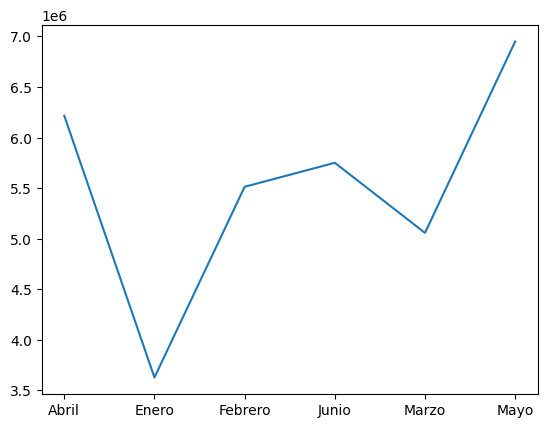

In [24]:
plt.plot(ventas_mensuales.index, ventas_mensuales.values)

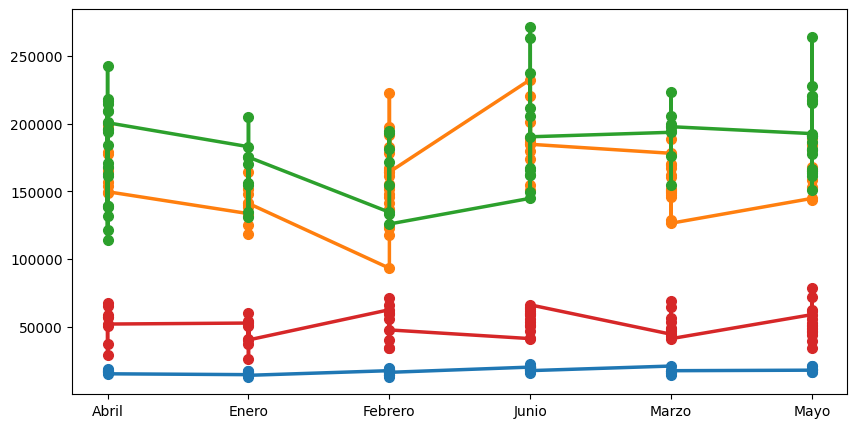

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))


for i, cat in enumerate(df['categoria'].unique()):
    subset = df[df['categoria'] == cat].sort_values('mes')
    
    ax.plot(
        subset['mes'],
        subset['ingresos'],
        linewidth=2.5,
        marker='o',
        markersize=7,
        label=cat,
        alpha=1
    )

In [33]:
"""
se usan juntos porque uno controla la posicion y el otro la etiqueta visible
"""

'\nse usan juntos porque uno controla la posicion y el otro la etiqueta visible\n'

In [39]:
#alpha=1 --> controla la transpariencia 0 == completamente transparente 1== muy marcado

In [41]:
ventas_por_mes = df.groupby('mes')['unidades'].sum()

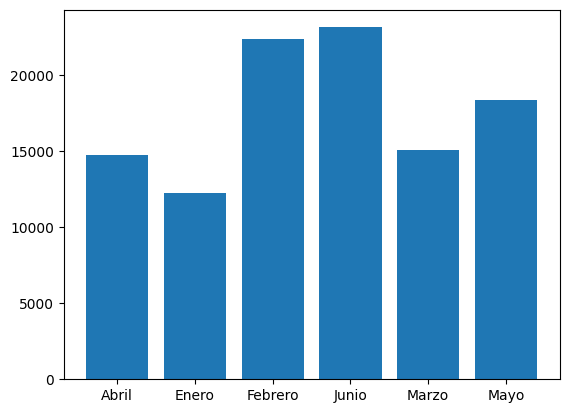

In [52]:
plt.bar(ventas_por_mes.index, ventas_por_mes.values)
colores = [
    'orange' if valor > 1400 else 'steelblue'
    for valor in ventas_por_mes.values
]

In [53]:
# la diferencia entre bar y barh es la orientacion en que se muestran las barras, usaria barh para un contecto empresarial

In [54]:
#los spines son los bordes del grafico si los quitas se ve algo mas minimalista

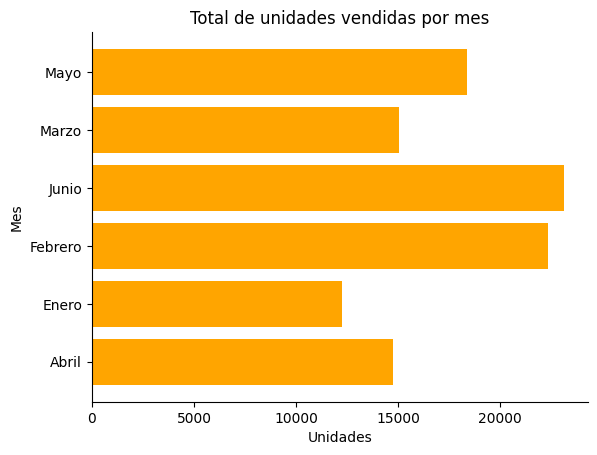

In [56]:
fig, ax = plt.subplots()

ax.barh(ventas_por_mes.index, ventas_por_mes.values, color=colores)

ax.set_title('Total de unidades vendidas por mes')
ax.set_xlabel('Unidades')
ax.set_ylabel('Mes')

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Text(0, 0.5, 'NPS')

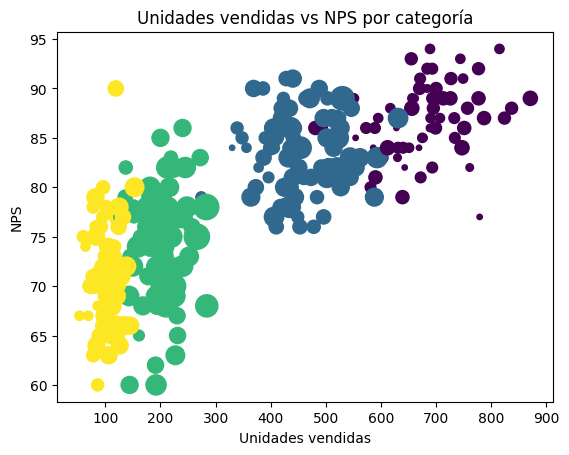

In [63]:
fig, ax = plt.subplots()
scatter = ax.scatter(
    df['unidades'], 
    df['nps'],
    c=pd.factorize(df['categoria'])[0],  
    s=df['devueltos'] * 15,              
)
ax.set_title('Unidades vendidas vs NPS por categoría')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('NPS')

In [65]:
#No se ve una relación lineal clara entre las unidades vendidas y el NPS.

In [66]:
#se hace para escalar el tamaño de los puntos y hacerlos visibles.

In [69]:
"""
Eje X-> Unidades vendidas
Eje Y-> NPS (satisfacción del cliente)
Color-> Categoría del producto
Tamaño-> Cantidad de devoluciones
"""

'\nEje X-> Unidades vendidas\nEje Y-> NPS (satisfacción del cliente)\nColor-> Categoría del producto\nTamaño-> Cantidad de devoluciones\n'

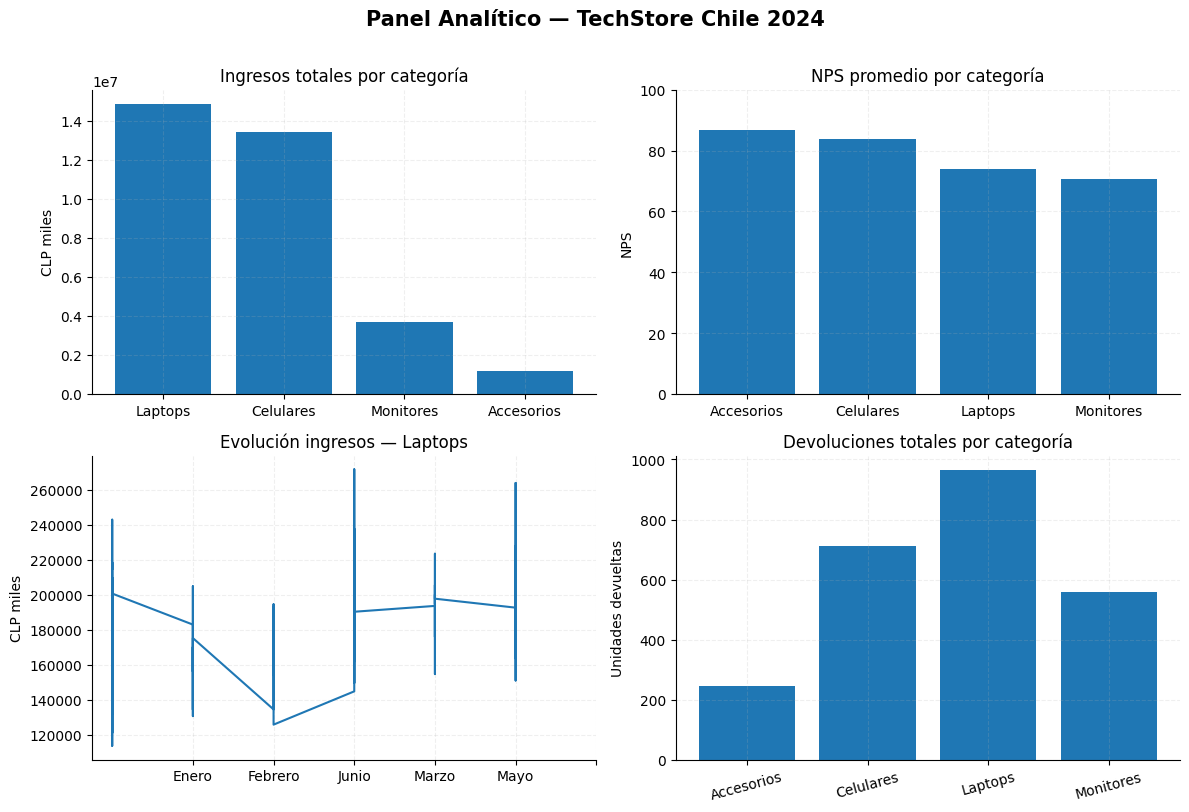

In [72]:
ingresos_cat = df.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)
nps_cat = df.groupby('categoria')['nps'].mean()
dev_cat = df.groupby('categoria')['devueltos'].sum()
laptops = df[df['categoria'] == 'Laptops'].sort_values('mes')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

fig.suptitle('Panel Analítico — TechStore Chile 2024', fontsize=15, fontweight='bold', y=1.01)

axes[0,0].bar(ingresos_cat.index, ingresos_cat.values)
axes[0,0].set_title('Ingresos totales por categoría')
axes[0,0].set_ylabel('CLP miles')

axes[0,1].bar(nps_cat.index, nps_cat.values)
axes[0,1].set_title('NPS promedio por categoría')
axes[0,1].set_ylabel('NPS')
axes[0,1].set_ylim(0, 100)

axes[1,0].plot(laptops['mes'], laptops['ingresos'])
axes[1,0].set_title('Evolución ingresos — Laptops')
axes[1,0].set_xticks(range(1, 7))
axes[1,0].set_ylabel('CLP miles')

axes[1,1].bar(dev_cat.index, dev_cat.values)
axes[1,1].set_title('Devoluciones totales por categoría')
axes[1,1].set_ylabel('Unidades devueltas')
axes[1,1].tick_params(axis='x', rotation=15)

for ax in axes.flat:
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [75]:
#El panel muestra que las categorias con mayores ingresos no necesariamente tienen el mejor NPS y algunas concentran mas devoluciones

In [76]:
#Se utiliza fig.suptitle() para agregar un titulo general a toda la figura
#mientras que ax.set_title() solo define titulos individuales para cada subgrafico

In [77]:
#axes.flat permite recorrer todos los subgraficos en un solo bucle

In [78]:
ingresos_mes = df.groupby('mes')['ingresos'].sum().reset_index()
unidades_mes = df.groupby('mes')['unidades'].sum().reset_index()

meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']

ingresos_mes['mes_label'] = meses_labels
ingresos_mes['ingresos_fmt'] = ingresos_mes['ingresos'].map(lambda x: f'${x:,.0f}K')
ingresos_mes['unidades'] = unidades_mes['unidades']

source = ColumnDataSource(ingresos_mes)

hover = HoverTool(tooltips=[
    ('Mes', '@mes_label'),
    ('Ingresos', '@ingresos_fmt'),
    ('Unidades', '@unidades')
])

p = figure(x_range=ingresos_mes['mes_label'], title='Ingresos por mes (Bokeh)', height=350)

p.add_tools(hover)

p.vbar(
    x='mes_label',
    top='ingresos',
    source=source,
    width=0.65,
    color='#0D9488',
    line_color='#065F52',
    alpha=0.85,
)

p.xgrid.grid_line_color = None
p.ygrid.grid_line_alpha = 0.3
p.yaxis.axis_label = 'Ingresos (CLP miles)'
p.xaxis.axis_label = 'Mes'
p.title.text_font_size = '13px'

show(p)

In [79]:
#Permite organizar los datos en una estructura centralizada que facilita la interaccion

In [80]:
#@mes_label hace referencia a una columna del ColumnDataSource
#su nombre debe coincidir con la clave del diccionario o DF usado como fuente de datos